In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [19]:
df=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\Machine Learning\\Datasets\\milk.csv",index_col=0)
df

,water,protein,fat,lactose,ash
Animal,,,,,
HORSE,90.1,2.6,1.0,6.9,0.35
ORANGUTAN,88.5,1.4,3.5,6.0,0.24
MONKEY,88.4,2.2,2.7,6.4,0.18
DONKEY,90.3,1.7,1.4,6.2,0.40
HIPPO,90.4,0.6,4.5,4.4,0.10
CAMEL,87.7,3.5,3.4,4.8,0.71
BISON,86.9,4.8,1.7,5.7,0.90
BUFFALO,82.1,5.9,7.9,4.7,0.78
GUINEA PIG,81.9,7.4,7.2,2.7,0.85


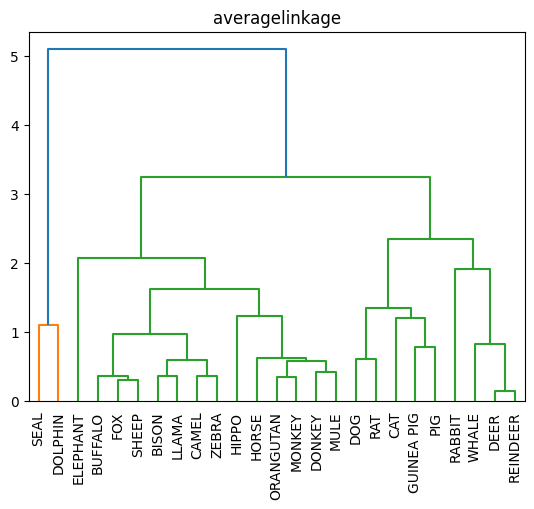

In [20]:
scaler=StandardScaler().set_output(transform='pandas')
df_scaled=scaler.fit_transform(df)
link='average'
mergings=linkage(df_scaled,method=link)
dendrogram(mergings,labels=list(df_scaled.index))
plt.title(link+'linkage')
plt.xticks(rotation=90)
plt.show()

In [21]:
Ks=[2,3,4,5]
scores=[]
for i in Ks:
    clust=AgglomerativeClustering(n_clusters=i)
    clust.fit(df_scaled)
    scores.append([i,silhouette_score(df_scaled,clust.labels_)])

df_scores=pd.DataFrame(scores,columns=['clusters','score'])
df_scores.sort_values('score',ascending=False)

,clusters,score
1,3,0.539160
0,2,0.525851
2,4,0.443481
3,5,0.398301


In [27]:
Ks=[2,3,4,5,7,6]
scores=[]
for i in Ks:
    clust=KMeans(n_clusters=i,random_state=26)
    clust.fit(df_scaled)
    scores.append([i,silhouette_score(df_scaled,clust.labels_)])
df_scores=pd.DataFrame(scores,columns=['clusters','score'])
df_scores.sort_values('score',ascending=False)

,clusters,score
0,2,0.525851
2,4,0.443481
3,5,0.409260
5,6,0.400535
4,7,0.391789
1,3,0.370679


## PCA

In [31]:
from sklearn.decomposition import PCA

In [40]:
prcomp=PCA().set_output(transform="pandas")
df_scaled=scaler.fit_transform(milk)
pca_data=prcomp.fit_transform(df_scaled)
km=KMeans(n_clusters=2,random_state=26)
km.fit(df_scaled)
pca_data["Cluster"]=km.labels_
pca_data["Cluster"]=pca_data["Cluster"].astype(str)

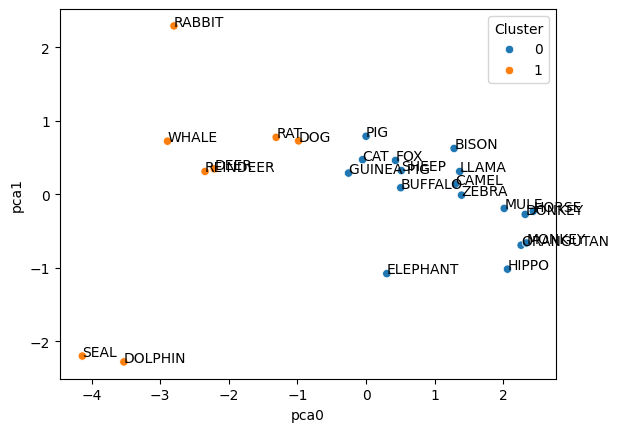

In [43]:
sns.scatterplot(data=pca_data,x="pca0",y="pca1",hue="Cluster")
for i in range(0,milk.shape[0]):
    plt.text(x=pca_data["pca0"].values[i],
            y=pca_data["pca1"].values[i],
            s=list(milk.index)[i])
plt.show()
